<a href="https://colab.research.google.com/github/Pradyumna-Shee/Snowflake-ELT-Dynamic_Tables-Streams_and_Tasks/blob/main/11_pipeline_and_security_proof_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install snowflake-connector-python -q

from google.colab import userdata
from cryptography.hazmat.primitives import serialization
import snowflake.connector

private_key_pem = userdata.get('SNOWFLAKE_PRIVATE_KEY').encode()
private_key = serialization.load_pem_private_key(private_key_pem, password=None)
private_key_der = private_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption(),
)

conn = snowflake.connector.connect(
    account='MKBNBME-UB36734',
    user='PRADYUMNASHEE',
    private_key=private_key_der,
    role='SEC_DATA_OWNER_ROLE',
    warehouse='SEC_FINANCIAL_DATA_PIPELINE_WAREHOUSE',
    database='SEC_FINANCIAL_DATA',
    schema='GOLD_SEC_ANALYTICS_REPORTING',
)
cur = conn.cursor()
print(cur.execute("SELECT CURRENT_USER(), CURRENT_ROLE()").fetchone())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0/100.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 7.4 MB/s eta 0:00:00
('PRADYUMNASHEE', 'SEC_DATA_OWNER_ROLE')


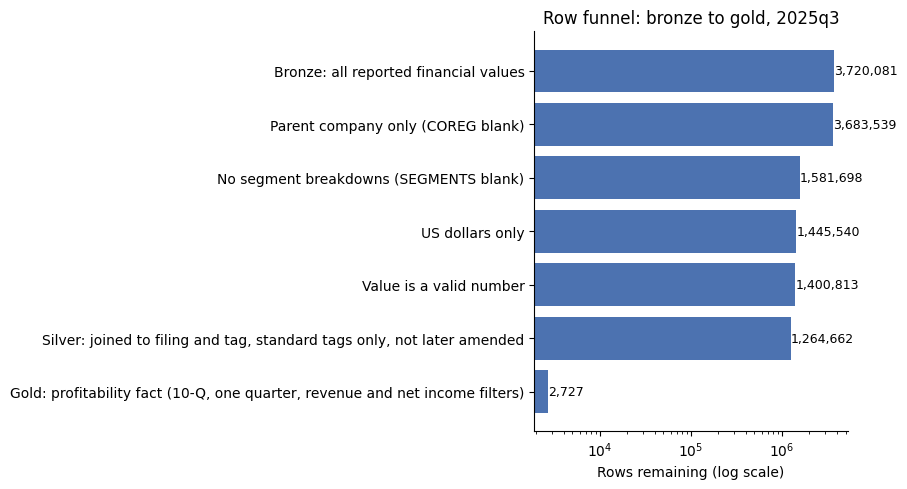

In [ ]:
import matplotlib.pyplot as plt

cur.execute("SELECT * FROM REPORT_DATA_OWNER_ROW_FUNNEL ORDER BY STEP_NUMBER")
rows = cur.fetchall()
steps = [r[1] for r in rows]
row_counts = [float(r[3]) for r in rows]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(steps, row_counts, color="#4C72B0")
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Rows remaining (log scale)")
ax.set_title("Row funnel: bronze to gold, 2025q3")
for bar, value in zip(bars, row_counts):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f"{value:,.0f}", va="center", ha="left", fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

roles_to_test = ['SEC_DATA_OWNER_ROLE', 'SEC_ANALYST_ROLE', 'SEC_INDUSTRY_ANALYST_ROLE', 'SEC_PUBLIC_REPORTER_ROLE']
results = []

for role in roles_to_test:
    cur.execute(f"USE ROLE {role}")

    cur.execute("SELECT DISTINCT INDUSTRY_DIVISION FROM REPORT_INDUSTRY_PROFITABILITY_PUBLIC ORDER BY 1")
    industries = [r[0] for r in cur.fetchall()]

    try:
        cur.execute("SELECT * FROM REPORT_INDUSTRY_PROFITABILITY LIMIT 1")
        columns = [desc[0] for desc in cur.description]
        sees_dollar_columns = 'TOTAL_REVENUE_USD' in columns
    except Exception:
        sees_dollar_columns = False

    results.append({
        'ROLE': role,
        'INDUSTRIES_VISIBLE': len(industries),
        'INDUSTRIES': ', '.join(industries),
        'SEES_DOLLAR_COLUMNS': sees_dollar_columns,
    })

pd.DataFrame(results)

,ROLE,INDUSTRIES_VISIBLE,INDUSTRIES,SEES_DOLLAR_COLUMNS
0,SEC_DATA_OWNER_ROLE,9,"Agriculture, Forestry and Fishing, Constructio...",True
1,SEC_ANALYST_ROLE,9,"Agriculture, Forestry and Fishing, Constructio...",True
2,SEC_INDUSTRY_ANALYST_ROLE,9,"Agriculture, Forestry and Fishing, Constructio...",True
3,SEC_PUBLIC_REPORTER_ROLE,9,"Agriculture, Forestry and Fishing, Constructio...",True


In [ ]:
cur.execute(f"USE ROLE {role}")
cur.execute("USE SECONDARY ROLES NONE")

In [ ]:
import pandas as pd

roles_to_test = ['SEC_DATA_OWNER_ROLE', 'SEC_ANALYST_ROLE', 'SEC_INDUSTRY_ANALYST_ROLE', 'SEC_PUBLIC_REPORTER_ROLE']
results = []

for role in roles_to_test:
    cur.execute(f"USE ROLE {role}")
    cur.execute("USE SECONDARY ROLES NONE")

    cur.execute("SELECT DISTINCT INDUSTRY_DIVISION FROM REPORT_INDUSTRY_PROFITABILITY_PUBLIC ORDER BY 1")
    industries = [r[0] for r in cur.fetchall()]

    try:
        cur.execute("SELECT * FROM REPORT_INDUSTRY_PROFITABILITY LIMIT 1")
        columns = [desc[0] for desc in cur.description]
        sees_dollar_columns = 'TOTAL_REVENUE_USD' in columns
    except Exception:
        sees_dollar_columns = False

    results.append({
        'ROLE': role,
        'INDUSTRIES_VISIBLE': len(industries),
        'INDUSTRIES': ', '.join(industries),
        'SEES_DOLLAR_COLUMNS': sees_dollar_columns,
    })

pd.DataFrame(results)

,ROLE,INDUSTRIES_VISIBLE,INDUSTRIES,SEES_DOLLAR_COLUMNS
0,SEC_DATA_OWNER_ROLE,9,"Agriculture, Forestry and Fishing, Constructio...",True
1,SEC_ANALYST_ROLE,9,"Agriculture, Forestry and Fishing, Constructio...",True
2,SEC_INDUSTRY_ANALYST_ROLE,2,"Manufacturing, Retail Trade",True
3,SEC_PUBLIC_REPORTER_ROLE,9,"Agriculture, Forestry and Fishing, Constructio...",False


In [ ]:
cur.close()
conn.close()